In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

# 1. Get final cells

In [3]:
adata = sc.read_h5ad("results/h5ad_raw/Blastocyst.gene_based.annotated.h5ad")
print("Before filtering:", adata.shape)
sc.pp.filter_cells(adata, min_genes=1000)
sc.pp.filter_cells(adata, min_counts=2000)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.calculate_qc_metrics(adata, inplace=True, log1p=True)
sc.pp.scrublet(adata)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
print("After filtering:", adata.shape)

Before filtering: (2661, 27524)
After filtering: (2655, 21489)


Mean: 0.047435152781780926
Std: 0.04913207970098356
Median: 0.036126056879323604


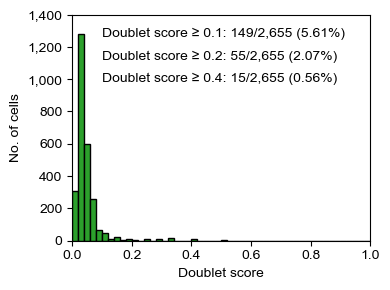

In [4]:
vs = adata.obs["doublet_score"]
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))
print("Median:", np.median(vs))
plt.figure(figsize=(4, 3))
plt.hist(vs, range=(0, 1), bins=50, edgecolor='black', color='C2', lw=1)
plt.xlim(0, 1)
ylim = 1400
plt.ylim(0, ylim)
plt.xlabel("Doublet score")
plt.ylabel("No. of cells")
ys = np.arange(0, ylim + 1, 200)
plt.yticks(ys, [format(y, ",") for y in ys])
plt.text(0.1, ylim * 0.9, "Doublet score ≥ 0.1: %s/%s (%.2f%%)" % (sum(vs>=0.1), format(len(vs), ","), sum(vs>=0.1)*100/len(vs)))
plt.text(0.1, ylim * 0.8, "Doublet score ≥ 0.2: %s/%s (%.2f%%)" % (sum(vs>=0.2), format(len(vs), ","), sum(vs>=0.2)*100/len(vs)))
plt.text(0.1, ylim * 0.7, "Doublet score ≥ 0.4: %s/%s (%.2f%%)" % (sum(vs>=0.4), format(len(vs), ","), sum(vs>=0.4)*100/len(vs)))
plt.tight_layout()
plt.savefig("figures/distribution_of_doublet_score.pdf")
plt.show()
plt.close()

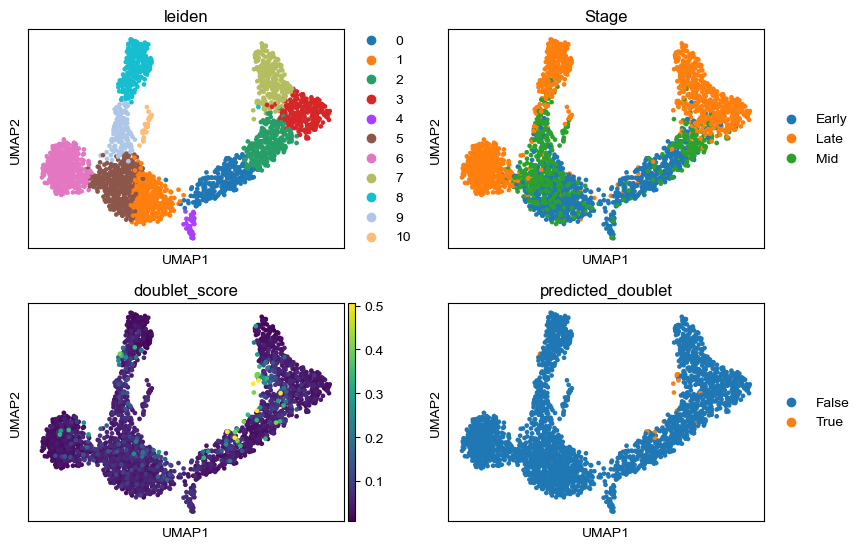

In [5]:
sc.pp.highly_variable_genes(adata, n_top_genes=500)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
with plt.rc_context({"figure.figsize": (4, 3)}):
    sc.pl.umap(adata, color=["leiden", "Stage", "doublet_score", "predicted_doublet"], ncols=2)

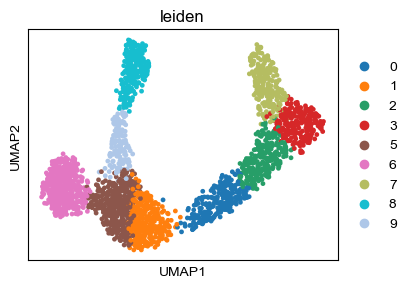

Final cells: 2535


In [6]:
adata2 = adata[(adata.obs["leiden"] != "4") & (adata.obs["leiden"] != "10") & (adata.obs["doublet_score"] < 0.2)]
with plt.rc_context({"figure.figsize": (4, 3)}):
    sc.pl.umap(adata2, color="leiden")
cells = list(sorted(adata2.obs.index))
print("Final cells:", len(cells))

In [7]:
with open("results/h5ad_qc/Blastocyst.final_cells.txt", "w+") as fw:
    for cell in cells:
        fw.write(cell + "\n")

# 2. Filter h5ad by cells

In [2]:
cells = set([line.strip() for line in open("results/h5ad_qc/Blastocyst.final_cells.txt")])
print("Number of cells:", len(cells))

Number of cells: 2535


In [3]:
def filter_h5ad_by_cells(infile, cells, prefix):
    path1 = prefix + ".annotated.h5ad"
    path2 = prefix + ".counts.csv"
    path3 = prefix + ".meta.csv"

    adata = sc.read_h5ad(infile)
    print(adata)
    adata = adata[adata.obs.index.isin(cells),:]
    print(adata)
    adata.write(path1, compression="gzip")

    mtx = pd.DataFrame(adata.X, index=adata.obs.index, columns=adata.var.index).T
    mtx.to_csv(path2)
    meta = adata.obs
    meta.to_csv(path3)

In [4]:
filter_h5ad_by_cells("results/h5ad_raw/Blastocyst.gene_based.annotated.h5ad", cells, "results/h5ad_qc/Blastocyst.gene_based")

AnnData object with n_obs × n_vars = 2661 × 27524
    obs: 'Run', 'Barcode', 'Species', 'CellType', 's4U', 'Time', 'ActD', 'Phase', 'IAA', 'Stage', 'Cell.Reads', 'Cell.Bases', 'Trimmed.Reads', 'Trimmed.Ratio', 'Mapped.Reads', 'Mapped.Ratio', 'Mito.Ratio', 'Filtered.Reads', 'Filtered.Ratio', 'FilteredClip.Reads', 'FilteredClip.Ratio', 'UMIs', 'mrUMIs', 'Duplicate.Reads', 'Duplicate.Ratio', 'Unique.Reads', 'Genes', 'Isoforms.Assembled', 'Isoforms.Known', 'AC.Ratio', 'AG.Ratio', 'AT.Ratio', 'CA.Ratio', 'CG.Ratio', 'CT.Ratio', 'GA.Ratio', 'GC.Ratio', 'GT.Ratio', 'TA.Ratio', 'TC.Ratio', 'TG.Ratio', 'Pe', 'Pc', 'SNR', 'mrUMIs.New', 'mrUMIs.New.Ratio', 'mrGenes', 'mrGenes.New'
    var: 'GeneID', 'GeneType', 'Chrom', 'Start', 'End', 'Strand'
    layers: 'new', 'total'
View of AnnData object with n_obs × n_vars = 2535 × 27524
    obs: 'Run', 'Barcode', 'Species', 'CellType', 's4U', 'Time', 'ActD', 'Phase', 'IAA', 'Stage', 'Cell.Reads', 'Cell.Bases', 'Trimmed.Reads', 'Trimmed.Ratio', 'Mapped.Rea

In [5]:
filter_h5ad_by_cells("results/h5ad_raw/Blastocyst.transcript_based.annotated.h5ad", cells, "results/h5ad_qc/Blastocyst.transcript_based")

AnnData object with n_obs × n_vars = 2661 × 70060
    obs: 'Run', 'Barcode', 'Species', 'CellType', 's4U', 'Time', 'ActD', 'Phase', 'IAA', 'Stage', 'Cell.Reads', 'Cell.Bases', 'Trimmed.Reads', 'Trimmed.Ratio', 'Mapped.Reads', 'Mapped.Ratio', 'Mito.Ratio', 'Filtered.Reads', 'Filtered.Ratio', 'FilteredClip.Reads', 'FilteredClip.Ratio', 'UMIs', 'mrUMIs', 'Duplicate.Reads', 'Duplicate.Ratio', 'Unique.Reads', 'Genes', 'Isoforms.Assembled', 'Isoforms.Known', 'AC.Ratio', 'AG.Ratio', 'AT.Ratio', 'CA.Ratio', 'CG.Ratio', 'CT.Ratio', 'GA.Ratio', 'GC.Ratio', 'GT.Ratio', 'TA.Ratio', 'TC.Ratio', 'TG.Ratio', 'Pe', 'Pc', 'SNR', 'mrUMIs.New', 'mrUMIs.New.Ratio', 'mrGenes', 'mrGenes.New'
    var: 'TranscriptID', 'TranscriptType', 'GeneID', 'GeneName', 'GeneType', 'Chrom', 'Start', 'End', 'Strand'
    layers: 'new', 'total'
View of AnnData object with n_obs × n_vars = 2535 × 70060
    obs: 'Run', 'Barcode', 'Species', 'CellType', 's4U', 'Time', 'ActD', 'Phase', 'IAA', 'Stage', 'Cell.Reads', 'Cell.Bases',